<a href="https://colab.research.google.com/github/axyojp/katago-on-colab/blob/main/katago-on-colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KataGo install

In [1]:
%%bash
nvidia-smi
echo ""
nvcc --version

Tue Jan  6 16:42:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   37C    P0             56W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
%%bash
# KataGo install セクションの内容を一括実行するスクリプト

# 1. 依存ライブラリのインストール (iDhMqcHDIq0N, s7Rk1nSdLabW)
sudo apt-get update
sudo apt-get install -y libzip4 libgoogle-perftools-dev opencl-headers ocl-icd-libopencl1 ocl-icd-opencl-dev
sudo apt-get install -y libcudnn8

# 2. KataGo本体のダウンロードと解凍 (GXgg3vypIRAi)
# https://github.com/lightvector/KataGo/releases
wget -nc https://github.com/lightvector/KataGo/releases/download/v1.16.4/katago-v1.16.4-cuda12.1-cudnn8.9.7-linux-x64.zip
unzip -o katago-v1.16.4-cuda12.1-cudnn8.9.7-linux-x64.zip -d katago
chmod +x katago/katago

# 3. モデルのダウンロード (sRQEjUVYJ288)
# https://katagotraining.org/
# https://katagotraining.org/networks/
cd katago
wget -nc https://media.katagotraining.org/uploaded/networks/models/kata1/kata1-b28c512nbt-s12163512064-d5648012427.bin.gz


Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Fetched 255 kB in 2s (151 kB/s)
Reading package lists...
Reading package lists...
Building dependency tree...
Reading state information...
libgoogle-perftools-dev is already the newest version (2.9.1-0ubuntu3).
libz

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
File ‘katago-v1.16.4-cuda12.1-cudnn8.9.7-linux-x64.zip’ already there; not retrieving.

File ‘kata1-b28c512nbt-s12163512064-d5648012427.bin.gz’ already there; not retrieving.



## 設定ファイル作成（サンプルとして）

In [40]:
%%writefile katago/gtp.cfg

# Config for KataGo C++ GTP engine
# Optimized for NVIDIA A100 (80GB VRAM) & High System RAM (167GB)

# ===========================================================================
# Logs and files
# ===========================================================================
logDir = gtp_logs
logAllGTPCommunication = true
logSearchInfo = true
logSearchInfoForChosenMove = false
logToStderr = false

# ===========================================================================
# Analysis
# ===========================================================================
analysisPVLen = 15
reportAnalysisWinratesAs = SIDETOMOVE

# ===========================================================================
# Rules
# ===========================================================================
koRule = SIMPLE
scoringRule = TERRITORY
taxRule = SEKI
multiStoneSuicideLegal = false
hasButton = false
whiteHandicapBonus = 0
friendlyPassOk = false

# ===========================================================================
# Bot behavior
# ===========================================================================
allowResignation = true
resignThreshold = -0.90
resignConsecTurns = 3
ponderingEnabled = true

# ===========================================================================
# Search limits
# ===========================================================================
# A100の計算力を受け止めるためスレッド数は256を維持
numSearchThreads = 256
lagBuffer = 1.0

searchFactorAfterOnePass = 0.50
searchFactorAfterTwoPass = 0.25
searchFactorWhenWinning = 0.40
searchFactorWhenWinningThreshold = 0.95

# ===========================================================================
# GPU settings
# ===========================================================================

# バッチサイズは256で十分強力ですが、VRAMが余りまくっているので
# 余裕があれば 300〜400 などを試しても良いですが、まずは256で安定させます。
nnMaxBatchSize = 256

# ★ここが最大の変更点★
# キャッシュサイズを「2の25乗」にします。
# これにより約3355万局面を記憶でき、システムメモリを数十GB消費して
# 読みの重複を極限まで減らします。
nnCacheSizePowerOfTwo = 25

# キャッシュが大きいので管理用Mutexも増やします
nnMutexPoolSizePowerOfTwo = 19

# ===========================================================================
# Root move selection and biases
# ===========================================================================
chosenMoveTemperatureEarly = 0.5
chosenMoveTemperatureHalflife = 19
chosenMoveTemperature = 0.10
chosenMoveSubtract = 0
chosenMovePrune = 1
useLcbForSelection = true
lcbStdevs = 5.0
minVisitPropForLCB = 0.15

# ===========================================================================
# Internal params
# ===========================================================================
winLossUtilityFactor = 1.0
staticScoreUtilityFactor = 0.10
dynamicScoreUtilityFactor = 0.30
noResultUtilityForWhite = 0.0
drawEquivalentWinsForWhite = 0.5
cpuctExploration = 1.0
cpuctExplorationLog = 0.45
rootEndingBonusPoints = 0.5
rootPruneUselessMoves = true
useGraphSearch = true

Overwriting katago/gtp.cfg


In [41]:
!cat ./katago/gtp.cfg


# Config for KataGo C++ GTP engine
# Optimized for NVIDIA A100 (80GB VRAM) & High System RAM (167GB)

# ===========================================================================
# Logs and files
# ===========================================================================
logDir = gtp_logs
logAllGTPCommunication = true
logSearchInfo = true
logSearchInfoForChosenMove = false
logToStderr = false

# ===========================================================================
# Analysis
# ===========================================================================
analysisPVLen = 15
reportAnalysisWinratesAs = SIDETOMOVE

# ===========================================================================
# Rules
# ===========================================================================
koRule = SIMPLE
scoringRule = TERRITORY
taxRule = SEKI
multiStoneSuicideLegal = false
hasButton = false
whiteHandicapBonus = 0
friendlyPassOk = false

# =========================================================

In [42]:
# とりあえずベンチマークしてみる
!./katago/katago benchmark -model ./katago/kata1-b28c512nbt-s12163512064-d5648012427.bin.gz -config ./katago/gtp.cfg -t 256 -override-config nnMaxBatchSize=256

2026-01-06 17:59:54+0000: Running with following config:
allowResignation = true
analysisPVLen = 15
chosenMovePrune = 1
chosenMoveSubtract = 0
chosenMoveTemperature = 0.10
chosenMoveTemperatureEarly = 0.5
chosenMoveTemperatureHalflife = 19
cpuctExploration = 1.0
cpuctExplorationLog = 0.45
drawEquivalentWinsForWhite = 0.5
dynamicScoreUtilityFactor = 0.30
friendlyPassOk = false
hasButton = false
koRule = SIMPLE
lagBuffer = 1.0
lcbStdevs = 5.0
logAllGTPCommunication = true
logDir = gtp_logs
logSearchInfo = true
logSearchInfoForChosenMove = false
logToStderr = false
minVisitPropForLCB = 0.15
multiStoneSuicideLegal = false
nnCacheSizePowerOfTwo = 25
nnMaxBatchSize = 256
nnMutexPoolSizePowerOfTwo = 19
noResultUtilityForWhite = 0.0
numSearchThreads = 256
ponderingEnabled = true
reportAnalysisWinratesAs = SIDETOMOVE
resignConsecTurns = 3
resignThreshold = -0.90
rootEndingBonusPoints = 0.5
rootPruneUselessMoves = true
scoringRule = TERRITORY
searchFactorAfterOnePass = 0.50
searchFactorAfterTwoP

## 設定ファイルの作成（ベンチマークしながら自動作成）

In [5]:
# 上記の暫定ファイルではなく環境にあわせて設定ファイルを作りたい時に、このセルを実行する。
!./katago/katago benchmark -config ./katago/gtp.cfg -model ./katago/kata1-b28c512nbt-s12163512064-d5648012427.bin.gz -tune

File ./katago/gtp.cfg already exists, okay to overwrite it with an entirely new config (y/n)?
y

RULES

What rules should KataGo use by default for play and analysis?
(chinese, japanese, korean, tromp-taylor, aga, chinese-ogs, new-zealand, bga, stone-scoring, aga-button):
japanese

SEARCH LIMITS

When playing games, KataGo will always obey the time controls given by the GUI/tournament/match/online server.
But you can specify an additional limit to make KataGo move much faster. This does NOT affect analysis/review,
only affects playing games. Add a limit? (y/n) (default n):


NOTE: No limits configured for KataGo. KataGo will obey time controls provided by the GUI or server or match script
but if they don't specify any, when playing games KataGo may think forever without moving. (press enter to continue)


When playing games, KataGo can optionally ponder during the opponent's turn. This gives faster/stronger play
in real games but should NOT be enabled if you are running tests with fixe

In [29]:
!cat ./katago/gtp.cfg


# Config for KataGo C++ GTP engine, i.e. "./katago.exe gtp"

# In this config, when a parameter is given as a commented out value,
# that value also is the default value, unless described otherwise. You can
# uncomment it (remove the pound sign) and change it if you want.

# ===========================================================================
# Command-line usage
# ===========================================================================
# All of the below values may be set or overridden via command-line arguments:
#
# -override-config KEY=VALUE,KEY=VALUE,...

# ===========================================================================
# Logs and files
# ===========================================================================
# This section defines where and what logging information is produced.

# Each run of KataGo will log to a separate file in this dir.
# This is the default.
logDir = gtp_logs
# Uncomment and specify this instead of logDir to write separate dated subd

## Katago 動作確認

In [38]:
!./katago/katago gtp -config ./katago/gtp.cfg -model ./katago/kata1-b28c512nbt-s12163512064-d5648012427.bin.gz

KataGo v1.16.4
Using Japanese rules initially, unless GTP/GUI overrides this
Initializing board with boardXSize 19 boardYSize 19
Loaded config ./katago/gtp.cfg
Loaded model ./katago/kata1-b28c512nbt-s12163512064-d5648012427.bin.gz
Model name: kata1-b28c512nbt-s12163512064-d5648012427
GTP ready, beginning main protocol loop
genmove black
= R16

^C


# CLI 版を動かす。

## 動いている様子

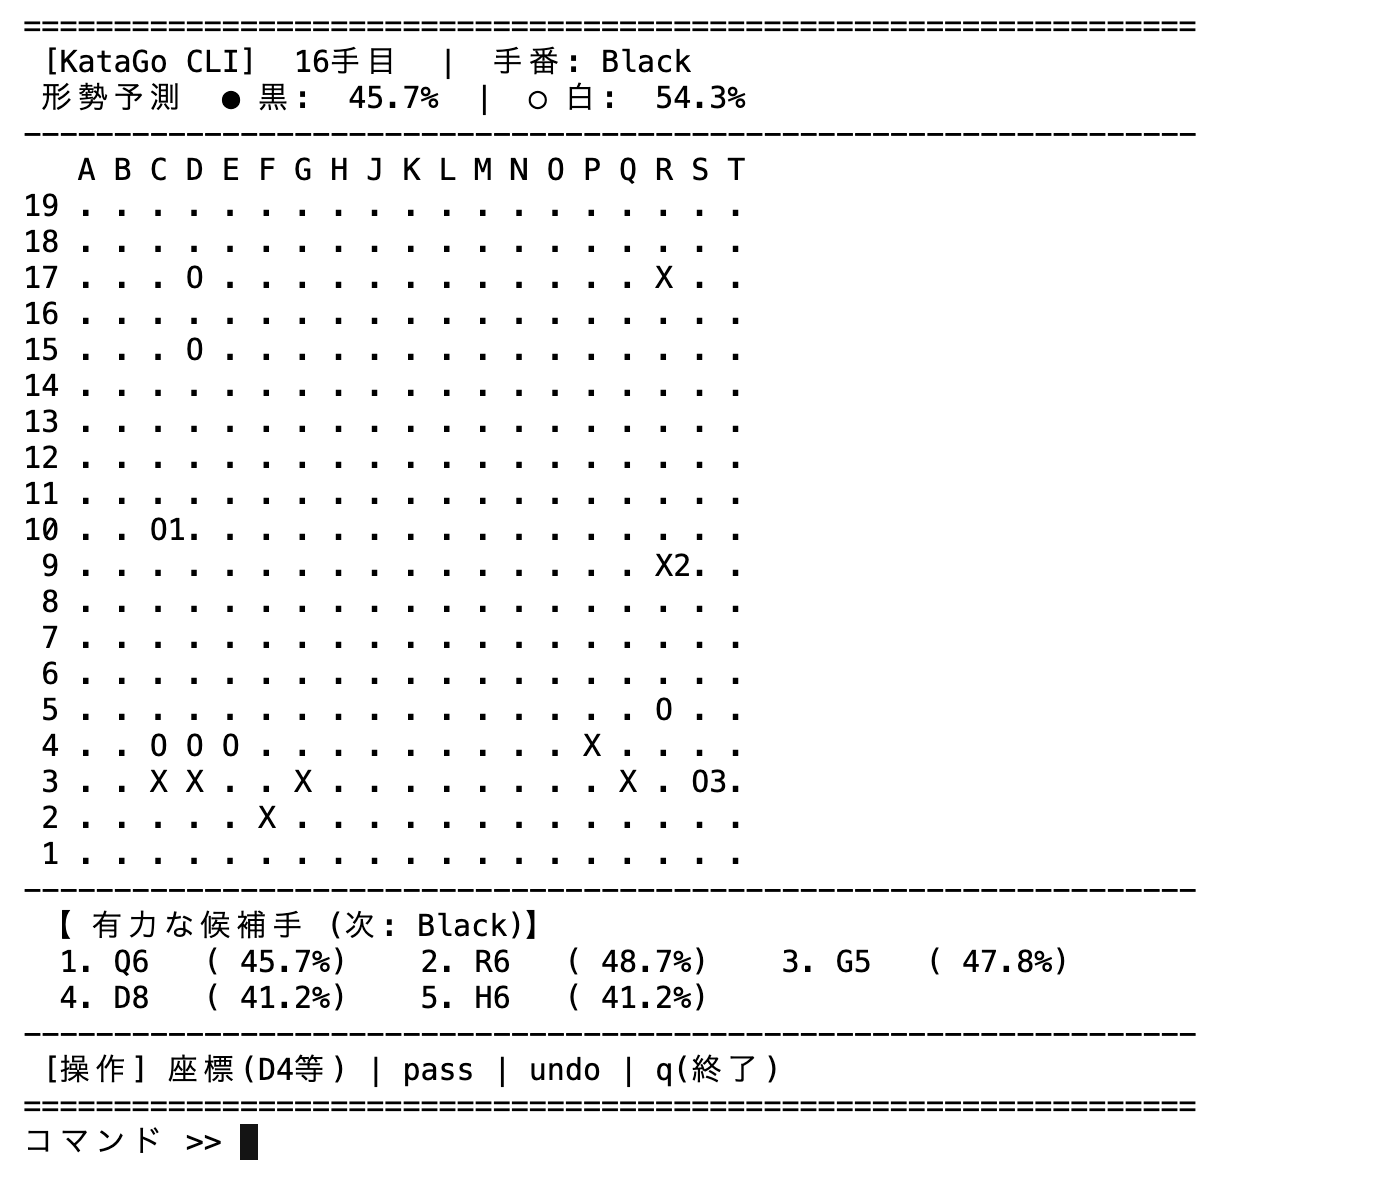

## 実際に動かす

In [7]:
%%writefile katago_wrapper.py
import subprocess
import time
import os
import sys
import select

# --- 設定（環境に合わせて書き換えてください） ---
KATAGO_PATH = "./katago/katago"
MODEL_PATH = "./katago/kata1-b28c512nbt-s12163512064-d5648012427.bin.gz"
CONFIG_PATH = "./katago/gtp.cfg"
# ------------------------------------------

class KataGoWrapper:
    def __init__(self):
        cmd = [KATAGO_PATH, "gtp", "-model", MODEL_PATH, "-config", CONFIG_PATH]
        self.proc = subprocess.Popen(
            cmd, stdin=subprocess.PIPE, stdout=subprocess.PIPE,
            stderr=sys.stderr, text=True, bufsize=1
        )
        self.current_turn = "Black"
        self.move_count = 0
        self.winrate_black = 50.0
        self.top_moves = []
        self.last_error = ""

    def read_until_response(self, timeout=2.0):
        """GTPの応答（= または ?）が来るまで確実に読み取る"""
        lines = []
        start_time = time.time()
        while time.time() - start_time < timeout:
            r, _, _ = select.select([self.proc.stdout], [], [], 0.1)
            if r:
                line = self.proc.stdout.readline().rstrip()
                if "info move" in line: continue # 解析行は無視
                lines.append(line)
                if line.startswith("=") or line.startswith("?"):
                    return lines
        return lines

    def flush_output(self):
        """溜まっている残骸データをすべて読み捨てる"""
        while True:
            r, _, _ = select.select([self.proc.stdout], [], [], 0.05)
            if r:
                self.proc.stdout.readline()
            else:
                break

    def get_board(self):
        """盤面が表示されるまで執拗にリトライする"""
        for i in range(10):
            self.flush_output()
            self.proc.stdin.write("showboard\n")
            self.proc.stdin.flush()

            lines = self.read_until_response(timeout=0.5 + i*0.1)
            # 盤面らしい行（A B C または 縦座標の数字）が含まれているか確認
            if any("A B C" in l or (l.strip() and l.strip().split()[0].isdigit()) for l in lines):
                return lines
            time.sleep(0.2)
        return []

    def update_analysis(self):
        """勝率と候補手を取得"""
        self.flush_output()
        self.proc.stdin.write("kata-analyze interval 1\n")
        self.proc.stdin.flush()

        start_wait = time.time()
        while time.time() - start_wait < 3.0:
            r, _, _ = select.select([self.proc.stdout], [], [], 0.1)
            if r:
                line = self.proc.stdout.readline()
                if "info move" in line and "winrate" in line:
                    self.parse_moves(line)
                    break

        self.proc.stdin.write("\n")
        self.proc.stdin.flush()
        self.read_until_response(timeout=0.5)

    def parse_moves(self, line):
        move_infos = line.split("info move")[1:]
        parsed = []
        for info in move_infos[:5]:
            parts = info.split()
            try:
                m = parts[0]
                wr = float(parts[parts.index("winrate")+1]) * 100
                parsed.append((m, wr))
            except: continue
        self.top_moves = parsed
        if parsed:
            self.winrate_black = parsed[0][1] if self.current_turn == "Black" else 100 - parsed[0][1]

    def print_gui(self):
        board_lines = self.get_board()
        os.system('clear')
        wr_b = self.winrate_black if self.current_turn == "Black" else 100 - self.winrate_black
        wr_w = 100.0 - wr_b

        print("="*65)
        print(f" [KataGo CLI] {self.move_count:3}手目  |  手番: {self.current_turn}")
        print(f" 形勢予測  ● 黒: {wr_b:5.1f}%  |  ○ 白: {wr_w:5.1f}%")
        if self.last_error: print(f" 【警告】 {self.last_error}")
        print("-" * 65)

        for line in board_lines:
            l = line.lstrip('=').strip()
            if "A B C" in l: print("   " + l)
            elif l and l.split()[0].isdigit():
                num = l.split()[0]
                print(f"{num:>2}{l[len(num):]}")

        print("-" * 65)
        print(f" 【有力な候補手 (次: {self.current_turn})】")
        for i, (m, wr) in enumerate(self.top_moves, 1):
            d_wr = wr if self.current_turn == "Black" else (100 - wr)
            print(f"  {i}. {m:<4} ({d_wr:5.1f}%)", end="  ")
            if i == 3: print()
        print(f"\n" + "-" * 65)
        print(" [操作] 座標(D4等) | pass | undo | q(終了)")
        print("="*65)

    def run(self):
        print("[LOG] 初期化中... しばらくお待ちください")
        self.update_analysis()
        while True:
            self.print_gui()
            cmd = input("コマンド >> ").strip()
            if not cmd: continue
            if cmd.lower() == 'q': break

            if cmd.lower() == 'undo':
                self.proc.stdin.write("undo\n")
                self.proc.stdin.flush()
                self.read_until_response()
                self.current_turn = "White" if self.current_turn == "Black" else "Black"
                self.move_count = max(0, self.move_count - 1)
            elif cmd.lower() == 'pass' or len(cmd) >= 2:
                self.proc.stdin.write(f"play {self.current_turn.lower()} {cmd}\n")
                self.proc.stdin.flush()
                res = self.read_until_response()
                if any(r.startswith("=") for r in res):
                    self.current_turn = "White" if self.current_turn == "Black" else "Black"
                    self.move_count += 1
                    self.last_error = ""
                else:
                    self.last_error = f"無効な手です: {cmd}"

            print("\n[LOG] 解析中...")
            self.update_analysis()

if __name__ == "__main__":
    wrapper = KataGoWrapper()
    wrapper.run()

Overwriting katago_wrapper.py


In [8]:
!ls -ltr

total 35308
-rw-r--r-- 1 root root 36134328 Oct 20 14:17 katago-v1.16.4-cuda12.1-cudnn8.9.7-linux-x64.zip
drwxr-xr-x 1 root root     4096 Dec  9 14:42 sample_data
drwxr-xr-x 2 root root     4096 Jan  6 16:42 katago
drwxr-xr-x 2 root root     4096 Jan  6 16:44 gtp_logs
-rw-r--r-- 1 root root     5929 Jan  6 16:48 katago_wrapper.py


In [9]:
# Terminal を起動して実行しても良い。
!python katago_wrapper.py

[LOG] 初期化中... しばらくお待ちください
KataGo v1.16.4
Using Japanese rules initially, unless GTP/GUI overrides this
Initializing board with boardXSize 19 boardYSize 19
Loaded config ./katago/gtp.cfg
Loaded model ./katago/kata1-b28c512nbt-s12163512064-d5648012427.bin.gz
Model name: kata1-b28c512nbt-s12163512064-d5648012427
GTP ready, beginning main protocol loop
 [KataGo CLI]   0手目  |  手番: Black
 形勢予測  ● 黒:  50.0%  |  ○ 白:  50.0%
-----------------------------------------------------------------
   A B C D E F G H J K L M N O P Q R S T
19 . . . . . . . . . . . . . . . . . . .
18 . . . . . . . . . . . . . . . . . . .
17 . . . . . . . . . . . . . . . . . . .
16 . . . . . . . . . . . . . . . . . . .
15 . . . . . . . . . . . . . . . . . . .
14 . . . . . . . . . . . . . . . . . . .
13 . . . . . . . . . . . . . . . . . . .
12 . . . . . . . . . . . . . . . . . . .
11 . . . . . . . . . . . . . . . . . . .
10 . . . . . . . . . . . . . . . . . . .
 9 . . . . . . . . . . . . . . . . . . .
 8 . . . . . . . . . .

# GUI 版を動かす。

## 動いている様子

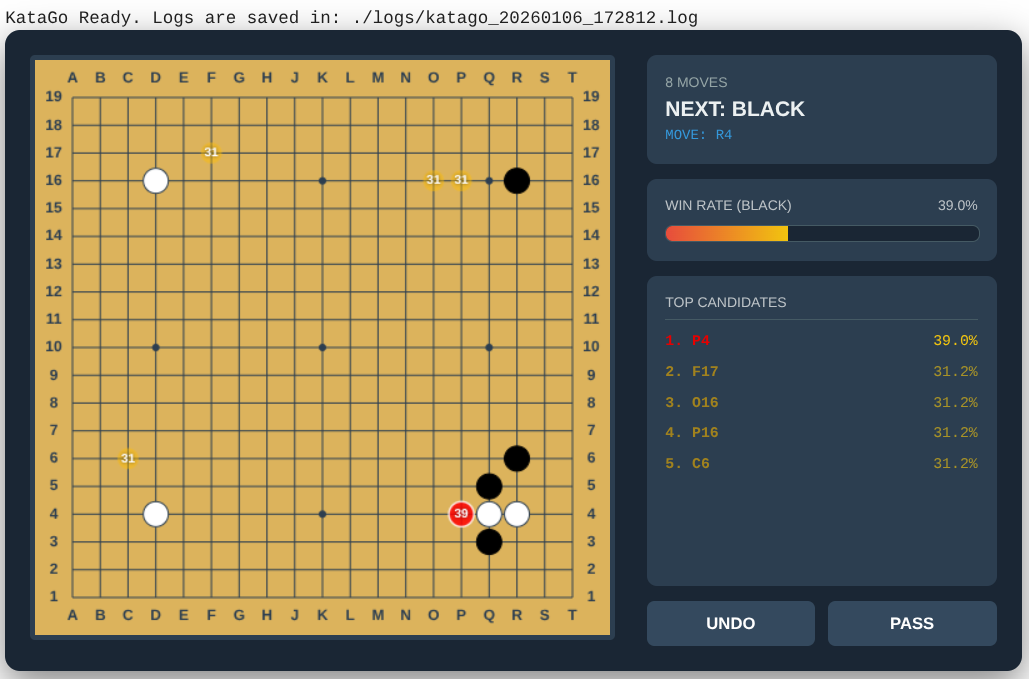

## 実際に動かす

In [44]:
import subprocess, time, select, os, sys, json, re
from datetime import datetime
from IPython.display import display, HTML
from google.colab import output

# --- KataGo 設定 ---
KATAGO_PATH = "./katago/katago"
MODEL_PATH = "./katago/kata1-b28c512nbt-s12163512064-d5648012427.bin.gz"
CONFIG_PATH = "./katago/gtp.cfg"
LOG_DIR = "./logs"

class KataGoGame:
    def __init__(self):
        self.current_turn = "Black"
        self.move_count = 0
        self.last_msg = "SYSTEM READY"
        self.win_rate = 50.0
        self.candidates = []
        self.is_ready = False

        # --- ログ設定 ---
        # logフォルダを作成
        os.makedirs(LOG_DIR, exist_ok=True)
        # ファイル名を生成 (例: katago_20231027_123000.log)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        self.log_path = os.path.join(LOG_DIR, f"katago_{timestamp}.log")
        self.write_log(f"--- SESSION START: {timestamp} ---")

        # エンジン起動
        self.proc = subprocess.Popen(
            [KATAGO_PATH, "gtp", "-model", MODEL_PATH, "-config", CONFIG_PATH],
            stdin=subprocess.PIPE, stdout=subprocess.PIPE, stderr=subprocess.PIPE,
            text=True, bufsize=1
        )

        self.write_log("[LOG] KataGo起動中... (約15秒)")
        # 起動待ちの間、画面には出さないのでスリープだけ
        time.sleep(15)

        # 初期化
        self.send_and_wait("boardsize 19")
        self.send_and_wait("komi 6.5")
        self.send_and_wait("clear_board")
        self.is_ready = True
        self.update_analysis()
        self.write_log("[LOG] 全ての準備が整いました")
        print(f"KataGo Ready. Logs are saved in: {self.log_path}") # 完了だけ画面に通知

    def write_log(self, msg):
        """ログファイルに書き出すメソッド"""
        t_str = datetime.now().strftime('%H:%M:%S')
        try:
            with open(self.log_path, "a", encoding="utf-8") as f:
                f.write(f"[{t_str}] {msg}\n")
        except Exception as e:
            # ログ書き込み失敗時は標準エラーに出しておく
            sys.stderr.write(f"Log Error: {e}\n")

    def send_and_wait(self, cmd, timeout=2.0):
        """GTPコマンドを送信し、ログファイルに出力しながら応答を待つ"""
        self.write_log(f"GTP SEND > {cmd}") # ★ファイル出力に変更
        self.proc.stdin.write(cmd + "\n")
        self.proc.stdin.flush()

        res_lines = []
        start_t = time.time()
        while time.time() - start_t < timeout:
            r, _, _ = select.select([self.proc.stdout], [], [], 0.1)
            if r:
                line = self.proc.stdout.readline().strip()
                if not line: continue
                self.write_log(f"GTP RECV < {line}") # ★ファイル出力に変更
                res_lines.append(line)
                if line.startswith("=") or line.startswith("?"):
                    break
        return res_lines

    def update_analysis(self):
        while True:
            r, _, _ = select.select([self.proc.stdout], [], [], 0.01)
            if r: self.proc.stdout.readline()
            else: break

        self.proc.stdin.write("kata-analyze interval 1\n")
        self.proc.stdin.flush()

        start_wait = time.time()
        while time.time() - start_wait < 3.0:
            r, _, _ = select.select([self.proc.stdout], [], [], 0.1)
            if r:
                line = self.proc.stdout.readline()
                if "info move" in line and "winrate" in line:
                    self.parse_kata_analyze(line)
                    break

        self.proc.stdin.write("\n")
        self.proc.stdin.flush()
        self.send_and_wait("", timeout=0.2)

    def parse_kata_analyze(self, line):
        move_infos = line.split("info move")[1:]
        parsed = []
        for info in move_infos[:5]:
            parts = info.split()
            try:
                m = parts[0]
                wr = float(parts[parts.index("winrate")+1]) * 100
                parsed.append({"move": m, "rate": wr})
            except: continue

        # ★ここに追加: 勝率が高い順(降順)にソート
        if parsed:
            parsed.sort(key=lambda x: x['rate'], reverse=True)

            self.candidates = parsed
            first_wr = parsed[0]["rate"]
            if self.current_turn == "Black":
                self.win_rate = first_wr
            else:
                self.win_rate = 100.0 - first_wr

    def get_state(self):
        # ★前回の修正（正規表現版）を適用済み
        if not self.is_ready: return {"ready": False}
        grid = [["." for _ in range(19)] for _ in range(19)]
        lines = self.send_and_wait("showboard")

        for line in lines:
            match = re.match(r'^\s*(\d+)\s+(.+)', line)
            if not match: continue

            row_num = int(match.group(1))
            if not (1 <= row_num <= 19): continue

            board_str = match.group(2)
            r_idx = 19 - row_num
            stones = re.findall(r'[.XO@#]', board_str)

            for c_idx, s in enumerate(stones):
                if c_idx < 19:
                    if s in ['X', '#']: grid[r_idx][c_idx] = 'X'
                    elif s in ['O', '@']: grid[r_idx][c_idx] = 'O'
                    else: grid[r_idx][c_idx] = '.'

        return {
            "ready": True, "grid": grid, "turn": self.current_turn,
            "move_count": self.move_count, "msg": self.last_msg,
            "win_rate": self.win_rate, "candidates": self.candidates
        }

# インスタンス作成
game = KataGoGame()

def api_get_state():
    return json.dumps(game.get_state(), ensure_ascii=False)

def api_handle_move(v):
    if v == 'undo':
        game.send_and_wait("undo")
        game.current_turn = "White" if game.current_turn == "Black" else "Black"
        game.move_count = max(0, game.move_count - 1)
        game.last_msg = "UNDO SUCCESS"
    elif v == 'pass':
        game.send_and_wait(f"play {game.current_turn.lower()} pass")
        game.current_turn = "White" if game.current_turn == "Black" else "Black"
        game.move_count += 1
        game.last_msg = "PASSED"
    else:
        cmd = f"play {game.current_turn.lower()} {v}"
        res = game.send_and_wait(cmd)

        if any(r.startswith("=") for r in res):
            game.current_turn = "White" if game.current_turn == "Black" else "Black"
            game.move_count += 1
            game.last_msg = f"MOVE: {v}"
        else:
            err_line = next((r for r in res if r.startswith("?")), "? Unknown Error")
            err_msg = err_line[1:].strip()
            game.last_msg = f"ERR: {err_msg}"
            # printの代わりにファイルログへ出力
            game.write_log(f"[ERROR] Move failed: {v}, Reason: {err_msg}")
            return

    game.update_analysis()

output.register_callback('api_get_state', api_get_state)
output.register_callback('api_handle_move', api_handle_move)




HTML_UI = """
<div id="gui-box" style="display:flex; padding:20px; background:#1a2634; color:#ecf0f1; border-radius:12px; width:fit-content; font-family: sans-serif; box-shadow: 0 10px 30px rgba(0,0,0,0.5);">
    <div style="position:relative;">
        <canvas id="goCanvas" width="460" height="460" style="background:#dcb35c; border:4px solid #2c3e50; cursor:pointer; border-radius:4px;"></canvas>
    </div>

    <div style="margin-left:25px; width:280px; display:flex; flex-direction:column; gap:12px;">
        <div style="background:#2c3e50; padding:15px; border-radius:8px;">
            <div id="info-count" style="font-size:0.8em; color:#95a5a6;">0 MOVES</div>
            <div id="info-turn" style="font-size:1.2em; font-weight:bold; margin:4px 0;">NEXT: BLACK</div>
            <div id="info-msg" style="color:#3498db; font-family:monospace; font-size:0.8em; overflow:hidden; text-overflow:ellipsis; white-space:nowrap;">SYSTEM READY</div>
        </div>

        <div style="background:#2c3e50; padding:15px; border-radius:8px;">
            <div style="display:flex; justify-content:space-between; font-size:0.8em; margin-bottom:8px; color:#bdc3c7;">
                <span>WIN RATE (BLACK)</span>
                <span id="wr-text">50.0%</span>
            </div>
            <div style="width:100%; background:#1a2634; height:12px; border-radius:6px; overflow:hidden; border:1px solid #455a64;">
                <div id="wr-bar" style="width:50%; background:linear-gradient(90deg, #e74c3c, #f1c40f); height:100%; transition: width 0.5s;"></div>
            </div>
        </div>

        <div style="background:#2c3e50; padding:15px; border-radius:8px; flex-grow:1;">
            <div style="font-size:0.8em; border-bottom:1px solid #455a64; padding-bottom:6px; margin-bottom:10px; color:#bdc3c7;">TOP CANDIDATES</div>
            <div id="cand-list" style="font-family:monospace; font-size:0.85em; display:flex; flex-direction:column; gap:6px;"></div>
        </div>

        <div style="display:grid; grid-template-columns: 1fr 1fr; gap:10px;">
            <button onclick="uiCmd('undo')" style="padding:10px; cursor:pointer; background:#34495e; color:white; border:none; border-radius:6px; font-weight:bold;">UNDO</button>
            <button onclick="uiCmd('pass')" style="padding:10px; cursor:pointer; background:#34495e; color:white; border:none; border-radius:6px; font-weight:bold;">PASS</button>
        </div>
    </div>
</div>

<script>
(function() {
    const canvas = document.getElementById('goCanvas');
    const ctx = canvas.getContext('2d');
    const cols = "ABCDEFGHJKLMNOPQRST";
    let isRequesting = false;

  async function sync() {
        if(isRequesting) return;
        isRequesting = true;
        try {
            const result = await google.colab.kernel.invokeFunction('api_get_state', [], {});
            let rawData = result.data['text/plain'];
            if (typeof rawData === 'string') {
                if (rawData.startsWith("'") && rawData.endsWith("'")) rawData = rawData.substring(1, rawData.length - 1);
                rawData = rawData.replace(/\\'/g, "'");
            }
            const data = typeof rawData === 'string' ? JSON.parse(rawData) : rawData;
            if(data && data.ready) draw(data);
        } catch(e) { console.error(e); }
        isRequesting = false;
    }
    setInterval(sync, 1500);

    function draw(data) {
        const pad = 30, size = 400, step = size/18;
        ctx.clearRect(0,0,460,460);

        // --- 盤面描画 ---
        ctx.textAlign = "center"; ctx.textBaseline = "middle";
        ctx.fillStyle = "#2c3e50"; ctx.font = "bold 12px sans-serif";
        for(let i=0; i<19; i++) {
            let p = pad + i*step;
            ctx.strokeStyle = "#2c3e50"; ctx.lineWidth = 1;
            ctx.beginPath(); ctx.moveTo(p, pad); ctx.lineTo(p, pad+size); ctx.stroke();
            ctx.beginPath(); ctx.moveTo(pad, p); ctx.lineTo(pad+size, p); ctx.stroke();
            ctx.fillText(cols[i], p, pad - 15); ctx.fillText(cols[i], p, pad + size + 15);
            let rowNum = 19 - i;
            ctx.fillText(rowNum, pad - 15, p); ctx.fillText(rowNum, pad + size + 15, p);
        }
        ctx.fillStyle = "#2c3e50";
        [3, 9, 15].forEach(r => [3, 9, 15].forEach(c => {
            ctx.beginPath(); ctx.arc(pad+c*step, pad+r*step, 3, 0, 7); ctx.fill();
        }));

        data.grid.forEach((row, r) => {
            row.forEach((s, c) => {
                if(s === 'X' || s === 'O') {
                    ctx.beginPath(); ctx.arc(pad+c*step, pad+r*step, step*0.45, 0, 7);
                    ctx.fillStyle = (s === 'X') ? "#000" : "#fff"; ctx.fill();
                    ctx.strokeStyle = (s === 'X') ? "#000" : "#2c3e50"; ctx.lineWidth = 1; ctx.stroke();
                }
            });
        });

        // --- 候補手の描画 (対数/指数的強調ロジック) ---
        if (data.candidates && data.candidates.length > 0) {
            // 候補手の中で最高の勝率を取得
            const maxRate = data.candidates.reduce((max, c) => Math.max(max, c.rate), 0);

            data.candidates.forEach((cand, index) => {
                if (cand.move === 'pass') return;

                const colChar = cand.move.charAt(0).toUpperCase();
                const rowStr = cand.move.substring(1);
                const rowNum = parseInt(rowStr);
                const cIdx = cols.indexOf(colChar);
                const rIdx = 19 - rowNum;

                if (cIdx >= 0 && rIdx >= 0 && rIdx < 19) {
                    const cx = pad + cIdx * step;
                    const cy = pad + rIdx * step;

                    // --- 強調ロジック ---
                    // 最高勝率に対する比率 (0.0 ~ 1.0)
                    const ratio = (maxRate > 0) ? (cand.rate / maxRate) : 0;

                    // 比率をべき乗して差を強調する (Gamma補正の逆のような処理)
                    // 値が1.0から少しでも下がると、急激に強調値が下がる
                    // 例: 比率0.9 (10%差) -> 0.9^6 = 0.53 (約50%の差に見える)
                    const emphasized = Math.pow(ratio, 6);

                    // 色相 (Hue): 0(赤) -> 60(黄)
                    // emphasized 1.0(最善) -> Hue 0 (真っ赤)
                    // emphasized 0.0(悪手) -> Hue 60 (黄色)
                    const hue = (1.0 - emphasized) * 60;

                    // 不透明度 (Alpha): 0.3(薄い) ~ 0.85(濃い)
                    // 最善手は濃く、悪い手は透ける
                    const alpha = 0.3 + (emphasized * 0.55);

                    // サイズ: 最善手は大きく、悪い手は少し小さく
                    const radius = (step * 0.35) + (emphasized * step * 0.1);

                    ctx.beginPath();
                    ctx.arc(cx, cy, radius, 0, 7);

                    // HSLAカラー設定
                    ctx.fillStyle = `hsla(${hue}, 100%, 50%, ${alpha})`;
                    ctx.fill();

                    // 白い縁取り (最善手付近のみ強くする)
                    if (emphasized > 0.5) {
                        ctx.strokeStyle = `rgba(255,255,255, ${0.4 + emphasized * 0.4})`;
                        ctx.lineWidth = 1.5;
                        ctx.stroke();
                    }

                    // テキスト
                    ctx.fillStyle = "#fff";
                    ctx.font = "bold 10px sans-serif";
                    ctx.shadowColor = "rgba(0,0,0,0.5)"; ctx.shadowBlur = 3;
                    ctx.fillText(Math.round(cand.rate), cx, cy);
                    ctx.shadowBlur = 0;
                }
            });
        }
        // -----------------------------------------

        // UI更新
        document.getElementById('info-count').innerText = data.move_count + " MOVES";
        document.getElementById('info-turn').innerText = "NEXT: " + data.turn.toUpperCase();
        document.getElementById('info-msg').innerText = data.msg;
        document.getElementById('wr-text').innerText = data.win_rate.toFixed(1) + "%";
        document.getElementById('wr-bar').style.width = data.win_rate + "%";

        // リスト表示も同じ色ロジックで連動
        let html = "";
        const maxRateList = data.candidates.reduce((max, c) => Math.max(max, c.rate), 0);
        data.candidates.forEach((c, i) => {
            const ratio = (maxRateList > 0) ? (c.rate / maxRateList) : 0;
            const emphasized = Math.pow(ratio, 6);
            const hue = (1.0 - emphasized) * 60;
            const alpha = 0.5 + (emphasized * 0.5);
            // CSS HSL文字列
            const colorStyle = `hsl(${hue}, 100%, 45%)`;
            const opacityStyle = alpha;

            html += `<div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:4px; opacity:${opacityStyle}">
                        <span style="color:${colorStyle}; font-weight:bold;">${i+1}. ${c.move}</span>
                        <span style="color:#f1c40f">${c.rate.toFixed(1)}%</span>
                     </div>`;
        });
        document.getElementById('cand-list').innerHTML = html || "Analyzing...";
    }

    canvas.onclick = async function(e) {
        const rect = canvas.getBoundingClientRect();
        const pad = 30, size = 400, step = size/18;
        const x = Math.round((e.clientX - rect.left - pad) / step);
        const y = Math.round((e.clientY - rect.top - pad) / step);
        if(x >= 0 && x < 19 && y >= 0 && y < 19) {
            const coord = cols[x] + (19 - y);
            document.getElementById('info-msg').innerText = "WAITING...";
            await google.colab.kernel.invokeFunction('api_handle_move', [coord], {});
            sync();
        }
    };
    window.uiCmd = async (v) => {
        await google.colab.kernel.invokeFunction('api_handle_move', [v], {});
        sync();
    };
    sync();
})();
</script>
"""
display(HTML(HTML_UI))

KataGo Ready. Logs are saved in: ./logs/katago_20260106_180338.log


## 終了処理（裏で動いているプロセスの掃除）

In [45]:
import psutil

def terminate_katago_processes():
    for proc in psutil.process_iter():
        try:
            # プロセス名またはコマンドライン引数に'katago'が含まれるプロセスを探す
            if "katago" in proc.name().lower() or "katago" in " ".join(proc.cmdline()).lower():
                print(f"[LOG] Terminating KataGo process: PID={proc.pid}, Name={proc.name()}")
                proc.terminate() # プロセスを終了する
                proc.wait(timeout=3) # 終了を待つ（最大3秒）
        except (psutil.NoSuchProcess, psutil.AccessDenied, psutil.ZombieProcess):
            pass # プロセスが存在しない、アクセス拒否、ゾンビプロセスなどの場合はスキップ

terminate_katago_processes()

# フロントエンドからのポーリング(Showboard)を停止させるために、
# グローバルの game オブジェクトの状態を更新する
if 'game' in globals() and game is not None:
    print("[LOG] Updating game object state to stopped.")
    game.is_ready = False
    if hasattr(game, 'proc') and game.proc:
        game.proc.poll() # 終了ステータスを更新

print("[LOG] KataGo processes terminated.")

[LOG] Terminating KataGo process: PID=110102, Name=katago
[LOG] Terminating KataGo process: PID=111870, Name=katago
[LOG] Terminating KataGo process: PID=112876, Name=katago
[LOG] Updating game object state to stopped.
[LOG] KataGo processes terminated.
